# Notebook 06 — Multi-Backend RQ1 Robustness

Study A. Re-run the seller simulation and seller-level SCS pipeline for each
Stage-1 backend and check that the SCS bin-level assignment-accuracy
monotonicity is a property of the SCS index itself, not of any one classifier
(first-paper Table 9 analogue).

The simulation seed is fixed across backends, so seller composition is
identical for every backend and only the item-level predictions differ. For
each backend the distribution-based decomposed SCS is binned into fixed SCS
ranges and mean assignment accuracy per bin is reported. A comparison table
and a grayscale figure summarize the result.

To switch to the GPU-trained PLM backends, set BACKENDS to the PLM prediction
files produced by notebook 00 (test_predictions_klue_roberta_base.csv, etc.).


Backends found: ['TF-IDF+LR', 'klue/roberta-base', 'klue/bert-base', 'KoELECTRA']
[TF-IDF+LR] sellers=1440 acc=0.7194 spearman=0.424 monotone=True
[klue/roberta-base] sellers=1440 acc=0.7319 spearman=0.388 monotone=False
[klue/bert-base] sellers=1440 acc=0.7243 spearman=0.409 monotone=True
[KoELECTRA] sellers=1440 acc=0.7236 spearman=0.419 monotone=False

          backend  n_sellers  overall_assign_acc  spearman_scs_assign  monotone_bins
        TF-IDF+LR       1440              0.7194               0.4243           True
klue/roberta-base       1440              0.7319               0.3881          False
   klue/bert-base       1440              0.7243               0.4087           True
        KoELECTRA       1440              0.7236               0.4195          False
          backend   n  mean_scs  assign_acc
        TF-IDF+LR 879    0.1130      0.5813
        TF-IDF+LR 355    0.2951      0.9155
        TF-IDF+LR 186    0.4725      0.9677
        TF-IDF+LR  18    0.6684      1.00

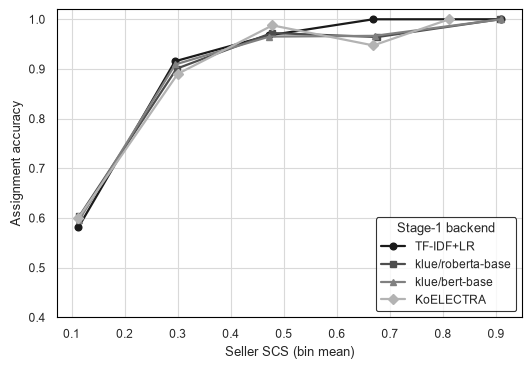

In [1]:
# %% ============================================================
# Notebook 06 — Multi-Backend RQ1 Robustness
# Imports, paths, backend registry
# ============================================================
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
ARTIFACT_DIR = os.path.join(ROOT, "artifacts")
TAB_DIR = os.path.join(ROOT, "results", "tables")
FIG_DIR = os.path.join(ROOT, "results", "figures")

# Backend registry: display name -> prediction CSV in artifacts/.
BACKENDS = {
    "TF-IDF+LR":  "test_predictions_tfidf_lr.csv",
    "klue/roberta-base": "test_predictions_klue_roberta_base.csv",
    "klue/bert-base":    "test_predictions_klue_bert_base.csv",
    "KoELECTRA":         "test_predictions_koelectra_base.csv",
}

# Fall back to whatever prediction files actually exist (keeps the notebook
# runnable before the PLMs are trained, e.g. during a CPU dry run).
available = {}
for name, fname in BACKENDS.items():
    path = os.path.join(ARTIFACT_DIR, fname)
    if os.path.exists(path):
        available[name] = fname
    elif name == "TF-IDF+LR" and os.path.exists(os.path.join(ARTIFACT_DIR, "test_predictions.csv")):
        available[name] = "test_predictions.csv"
print("Backends found:", list(available.keys()))

# %% ============================================================
# Fixed simulation design (mirrors notebook 01). The seed is fixed so
# the same virtual sellers are built for every backend.
# ============================================================
DOMINANT_REGIMES = {
    "focused":     (0.6, 1.0),
    "cross":       (0.3, 0.6),
    "diversified": (0.1, 0.3),
}
STORE_COUNTS = [1, 2, 3, 5]
ITEM_COUNTS = [30, 100, 300]
N_SELLERS_PER_CELL = 40
TILTS = ["easy", "neutral", "hard"]
SIM_SEED = 42

design_cells = [(r, s, n) for r in DOMINANT_REGIMES
                for s in STORE_COUNTS for n in ITEM_COUNTS]

# %% ============================================================
# Self-contained simulation + SCS functions (from notebooks 01-02).
# Difficulty tilt uses each backend's own per-category accuracy so the
# tilt is defined consistently within each backend.
# ============================================================
def build_pools(items, n_classes):
    return {c: items.index[items["label"] == c].to_numpy() for c in range(n_classes)}


def raw_entropy(p):
    p = np.asarray(p, dtype=float); p = p[p > 0]
    if p.size == 0:
        return 0.0
    return float(-(p * np.log(p)).sum())


def cat_counts(labels, n_classes):
    return np.bincount(labels, minlength=n_classes).astype(float)


def pick_dominant(tilt, easy_cats, hard_cats, n_classes, rng):
    if tilt == "easy":
        return int(rng.choice(easy_cats))
    if tilt == "hard":
        return int(rng.choice(hard_cats))
    return int(rng.integers(0, n_classes))


def synth_store(regime, n_items, pools, n_classes, rng, dom_cat):
    lo, hi = DOMINANT_REGIMES[regime]
    p_dom = rng.uniform(lo, hi)
    n_dom = int(round(n_items * p_dom)); n_rest = n_items - n_dom
    chosen = []
    if n_dom > 0:
        chosen.append(rng.choice(pools[dom_cat], size=n_dom, replace=True))
    if n_rest > 0:
        others = [c for c in range(n_classes) if c != dom_cat]
        k_cats = int(rng.integers(1, min(5, len(others)) + 1))
        ocats = rng.choice(others, size=k_cats, replace=False)
        split = rng.multinomial(n_rest, np.ones(k_cats) / k_cats)
        for c, k in zip(ocats, split):
            if k > 0:
                chosen.append(rng.choice(pools[int(c)], size=int(k), replace=True))
    return np.concatenate(chosen) if chosen else np.array([], dtype=int)


def run_backend(items, n_classes, seed):
    rng = np.random.default_rng(seed)
    pools = build_pools(items, n_classes)
    cat_acc = items.groupby("label")["correct"].mean().sort_values()
    easy_cats = cat_acc.index[cat_acc.values >= cat_acc.median()].to_numpy()
    hard_cats = cat_acc.index[cat_acc.values < cat_acc.median()].to_numpy()

    rows = []
    for (regime, n_stores, n_items) in design_cells:
        for k in range(N_SELLERS_PER_CELL):
            tilt = TILTS[k % len(TILTS)]
            dom_cat = pick_dominant(tilt, easy_cats, hard_cats, n_classes, rng)
            per_store = max(5, n_items // n_stores)
            stores = []
            for _ in range(n_stores):
                idx = synth_store(regime, per_store, pools, n_classes, rng, dom_cat)
                if len(idx) > 0:
                    stores.append(items.loc[idx])
            if not stores:
                continue
            seller = pd.concat(stores, ignore_index=True)
            store_ids = np.concatenate([[i] * len(s) for i, s in enumerate(stores)])

            # CWV assignment
            weighted = np.zeros(n_classes)
            for c, w in zip(seller["pred"].to_numpy(), seller["confidence"].to_numpy()):
                weighted[c] += w
            assigned = int(np.argmax(weighted))
            assign_correct = int(assigned == dom_cat)

            # distribution-based decomposed SCS: W_dist * B_s
            store_within, store_w, store_dom = [], [], []
            for i in range(n_stores):
                s = seller[store_ids == i]
                if len(s) == 0:
                    continue
                counts = cat_counts(s["pred"].to_numpy(), n_classes)
                N = counts.sum(); H = raw_entropy(counts / N)
                store_within.append((counts.max() / N) * (1.0 / (1.0 + H)))
                store_w.append(len(s))
                store_dom.append(int(np.argmax(counts)))
            W_dist = float(np.average(store_within, weights=store_w))
            dom_dist = cat_counts(np.array(store_dom), n_classes)
            dom_dist = dom_dist / dom_dist.sum()
            B_s = 1.0 / (1.0 + raw_entropy(dom_dist))
            scs = W_dist * B_s

            rows.append({"regime": regime, "n_stores": n_stores,
                         "scs_dist_decomp": scs, "assign_correct": assign_correct})
    return pd.DataFrame(rows)

# %% ============================================================
# Run every available backend and collect bin-level assignment
# accuracy over fixed SCS ranges.
# ============================================================
EDGES = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
per_backend_bins = {}
corr_rows = []

for name, fname in available.items():
    items = pd.read_csv(os.path.join(ARTIFACT_DIR, fname)).reset_index(drop=True)
    n_classes = int(items["label"].nunique())
    res = run_backend(items, n_classes, SIM_SEED)

    lab = pd.cut(res["scs_dist_decomp"], EDGES, include_lowest=True)
    binned = res.groupby(lab, observed=True).agg(
        n=("assign_correct", "size"),
        mean_scs=("scs_dist_decomp", "mean"),
        assign_acc=("assign_correct", "mean"),
    ).reset_index(drop=True)
    per_backend_bins[name] = binned

    sp, _ = spearmanr(res["scs_dist_decomp"], res["assign_correct"])
    mono = bool((np.diff(binned["assign_acc"].to_numpy()) >= -1e-9).all())
    corr_rows.append({"backend": name, "n_sellers": len(res),
                      "overall_assign_acc": res["assign_correct"].mean(),
                      "spearman_scs_assign": sp, "monotone_bins": mono})
    print(f"[{name}] sellers={len(res)} acc={res['assign_correct'].mean():.4f} "
          f"spearman={sp:.3f} monotone={mono}")

corr_tbl = pd.DataFrame(corr_rows)
corr_tbl.to_csv(os.path.join(TAB_DIR, "table_robustness_backends.csv"), index=False)
print()
print(corr_tbl.round(4).to_string(index=False))

# %% ============================================================
# Combined bin-level comparison table across backends
# (first-paper Table 9 analogue).
# ============================================================
frames = []
for name, b in per_backend_bins.items():
    bb = b.copy(); bb.insert(0, "backend", name)
    frames.append(bb)
combined = pd.concat(frames, ignore_index=True)
combined.to_csv(os.path.join(TAB_DIR, "table_robustness_binlevel.csv"), index=False)
print(combined.round(4).to_string(index=False))

# %% ============================================================
# Grayscale figure: SCS bin-level assignment accuracy across backends.
# No caption, 600 dpi, PNG + PDF.
# ============================================================
sns.set_theme(style="whitegrid", palette="gray", context="paper")
plt.rcParams.update({"savefig.dpi": 600, "font.size": 11,
                     "axes.edgecolor": "black", "axes.linewidth": 0.8,
                     "grid.color": "0.85"})

fig, ax = plt.subplots(figsize=(6, 4))
markers = ["o", "s", "^", "D", "v"]
grays = np.linspace(0.1, 0.7, len(per_backend_bins))
for (name, b), mk, gg in zip(per_backend_bins.items(), markers, grays):
    ax.plot(b["mean_scs"], b["assign_acc"], marker=mk, color=str(gg),
            linewidth=1.6, label=name)
ax.set_xlabel("Seller SCS (bin mean)")
ax.set_ylabel("Assignment accuracy")
ax.set_ylim(0.4, 1.02)
ax.legend(frameon=True, edgecolor="black", title="Stage-1 backend")
for ext in ("png", "pdf"):
    fig.savefig(os.path.join(FIG_DIR, f"fig9_rq1_backend_robustness.{ext}"),
                dpi=600, bbox_inches="tight")
plt.show()